## 축3 자가소비 적합성 분석
## 01. EDA

### 데이터 로드
- 축2 전처리 데이터 (`parking_preprocessed.csv`) 사용
- 서울시 공영주차장 742개 기준

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 시각화 스타일 설정
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df = pd.read_csv(
    r'C:\Users\seonu\Documents\DR-project\canopy\data\processed\parking_preprocessed.csv',
    encoding='utf-8-sig'
)

print(f"shape: {df.shape}")
print(f"\n컬럼:\n{df.columns.tolist()}")
print(f"\n첫 5행:")
print(df.head())

shape: (742, 9)

컬럼:
['pklt_nm', 'pklt_knd_nm', 'tpkct', 'add_crg_std', 'add_crg_std_filled', 'is_add_crg_imputed', 'lat', 'lot', 'addr']

첫 5행:
        pklt_nm pklt_knd_nm  tpkct  add_crg_std  add_crg_std_filled  \
0     15-가600구간      노상 주차장    1.0          NaN               400.0   
1         21-37      노외 주차장   13.0          NaN               400.0   
2           BYC      노상 주차장    1.0        500.0               500.0   
3  KBS별관뒤 노상주차장      노상 주차장    1.0       1000.0              1000.0   
4  KBS별관옆 노상주차장      노상 주차장    1.0       1000.0              1000.0   

   is_add_crg_imputed        lat         lot            addr  
0                True  37.548410  127.151580   강동구 명일동 583-0  
1                True  37.512281  127.085599   송파구 잠실동 348-0  
2               False  37.475325  126.886395  금천구 가산동 371-57  
3               False  37.526709  126.923800   영등포구 여의도동 4-5  
4               False  37.526709  126.923800   영등포구 여의도동 4-4  


### 기본 정보 확인
- 결측값, 데이터 타입, 기초 통계량 확인

In [2]:
# 데이터 타입 및 결측 확인
print("=== 데이터 타입 ===")
print(df.dtypes)

print("\n=== 결측값 ===")
print(df.isna().sum())

print("\n=== 기초 통계량 ===")
print(df[['tpkct', 'add_crg_std', 'add_crg_std_filled']].describe())

print("\n=== 노상/노외 분포 ===")
print(df['pklt_knd_nm'].value_counts())

=== 데이터 타입 ===
pklt_nm                   str
pklt_knd_nm               str
tpkct                 float64
add_crg_std           float64
add_crg_std_filled    float64
is_add_crg_imputed       bool
lat                   float64
lot                   float64
addr                      str
dtype: object

=== 결측값 ===
pklt_nm                 0
pklt_knd_nm             0
tpkct                   0
add_crg_std           161
add_crg_std_filled      0
is_add_crg_imputed      0
lat                     0
lot                     0
addr                    0
dtype: int64

=== 기초 통계량 ===
             tpkct  add_crg_std  add_crg_std_filled
count   742.000000   581.000000          742.000000
mean     84.836927   450.789189          439.768893
std     139.707190   289.391299          256.885321
min       1.000000    18.518519           18.518519
25%      10.250000   300.000000          300.000000
50%      47.500000   380.000000          400.000000
75%     108.000000   500.000000          500.000000
max    14

### 주요 변수 분포 시각화
- 노상/노외 비율
- 총 주차면수 분포
- 주차장 위치 분포 (지도)

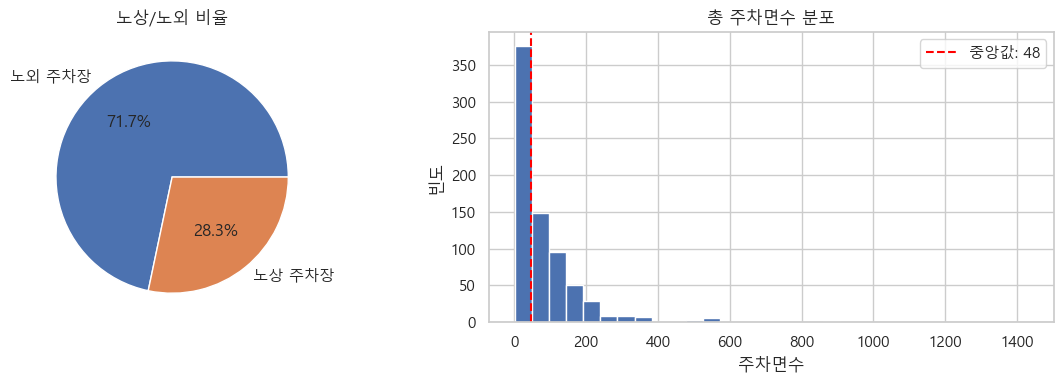

총 주차면수 기초통계:
count     742.000000
mean       84.836927
std       139.707190
min         1.000000
25%        10.250000
50%        47.500000
75%       108.000000
max      1431.000000
Name: tpkct, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 노상/노외 비율 파이차트
axes[0].pie(
    df['pklt_knd_nm'].value_counts(),
    labels=df['pklt_knd_nm'].value_counts().index,
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452']
)
axes[0].set_title('노상/노외 비율')

# 총 주차면수 분포 히스토그램
axes[1].hist(df['tpkct'], bins=30, color='#4C72B0', edgecolor='white')
axes[1].set_title('총 주차면수 분포')
axes[1].set_xlabel('주차면수')
axes[1].set_ylabel('빈도')
axes[1].axvline(df['tpkct'].median(), color='red', linestyle='--', label=f'중앙값: {df["tpkct"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\seonu\Documents\DR-project\canopy\output\figures\EDA_기본분포.png', dpi=150)
plt.show()

print(f"총 주차면수 기초통계:")
print(df['tpkct'].describe())

### EDA 결과 요약

**노상/노외 비율**
- 노외 주차장: 532개 (71.7%)
- 노상 주차장: 210개 (28.3%)
- 노외가 약 2.5배 많음

**총 주차면수 분포**
- 중앙값 48면으로 오른쪽으로 크게 치우친 분포 (우편향)
- 대부분 200면 이하에 집중, 최대 1,431면으로 편차 매우 큼
- 정규화 필수

### 주차장 위치 분포 (지도)
- 서울시 공영주차장 742개 위치 시각화
- 노상/노외 색상 구분

In [7]:
fig = go.Figure()

for knd, group in df.groupby('pklt_knd_nm'):
    fig.add_trace(go.Scattermap(
        lat=group['lat'],
        lon=group['lot'],
        mode='markers',
        marker=dict(size=6, color=colors[knd]),
        name=knd,
        text=group['pklt_nm'],
        hovertemplate='%{text}<br>위도: %{lat}<br>경도: %{lon}<extra></extra>'
    ))

fig.update_layout(
    map=dict(
        style='carto-positron',
        center=dict(lat=37.5665, lon=126.9780),
        zoom=10
    ),
    title='서울시 공영주차장 위치 분포 (742개)',
    height=600,
    legend=dict(x=0, y=1)
)

fig.show()

### 주차장 위치 분포 결과
- 742개 공영주차장이 서울 전역에 분포
- 노외(파란점)는 도심 및 강남권에 집중
- 노상(주황점)은 도심 외곽과 주거지역에 분포
- 강북 도심(종로·중구)과 강남권에 밀집도 높음

### 자치구별 주차장 수 분포
- 자치구별 노상/노외 주차장 수 확인

In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 자치구 추출
df['자치구'] = df['addr'].str.extract(r'(\S+구)')

# 자치구별 노상/노외 집계
gu_counts = df.groupby(['자치구', 'pklt_knd_nm']).size().unstack(fill_value=0)
gu_counts['합계'] = gu_counts.sum(axis=1)
gu_counts = gu_counts.sort_values('합계', ascending=True)

fig = go.Figure()

fig.add_trace(go.Bar(
    y=gu_counts.index,
    x=gu_counts['노외 주차장'],
    name='노외 주차장',
    orientation='h',
    marker_color='#4C72B0'
))

fig.add_trace(go.Bar(
    y=gu_counts.index,
    x=gu_counts['노상 주차장'],
    name='노상 주차장',
    orientation='h',
    marker_color='#DD8452'
))

fig.update_layout(
    title='자치구별 공영주차장 수 (노상/노외 구분)',
    barmode='stack',
    height=700,
    xaxis_title='주차장 수',
    yaxis_title='자치구'
)

fig.show()

### 자치구별 공영주차장 수 결과
- 영등포구(1위), 양천구(2위), 강남구(3위) 순으로 공영주차장 많음
- 영등포구는 노상 비율이 특히 높음
- 서대문구, 광진구, 성북구는 공영주차장 수가 적음
- 대부분 자치구에서 노외 비율이 노상보다 높음

### EDA 종합 요약

| 항목 | 내용 |
|------|------|
| 총 주차장 수 | 742개 |
| 노외 주차장 | 532개 (71.7%) |
| 노상 주차장 | 210개 (28.3%) |
| 총 주차면수 중앙값 | 48면 |
| 총 주차면수 범위 | 1 ~ 1,431면 |
| 결측값 | 축3 필요 컬럼 없음 |
| 주요 밀집 자치구 | 영등포구, 양천구, 강남구 |

→ 전처리 단계에서 OA-13122 원본에서 운영시간 붙이고 EV 데이터 조인 진행